#### CatBoost v2: agriculture population, with rel/attsch/occ added

Same as `train-catboost_v2_agri.ipynb` (population, wage formula, toggles), with three extra features added to test whether they help: `rel`, `attsch`, `occ`.

<div style="font-size: 10pt;">

What this notebook implements from the email:

- Zero-income (unpaid) respondents: included.
- Hours worked and second-job hours: included for the male model only.
- Employment status (`emps`): excluded. The with_emps diagnostic notebook showed that once zero income is included, this one variable drives 81% of female feature importance on its own, since unpaid family workers are coded there by definition.
- Employment stability (`empstab`): the email asked to include it. We found it correlates 0.73 with paid status within agriculture (regular work is mostly unpaid family labor, seasonal work is mostly hired paid labor), close to the same circularity as `emps`. Checked against the official HLFS data dictionary: both variables are correctly identified, so this is a real tradeoff, not a mix-up. It is now a setting (`INCLUDE_EMPSTAB`, Section 0b) so both versions can be compared directly.

Extra features tested here, the same three as `train-catboost_raw_with_zeros.ipynb`: `rel` (relationship to household head) and `attsch` (school attendance) correlate with male zero-wage status at 0.27 and 0.26, real signal rather than wage-derived. `occ` (occupation code) is a structural job characteristic, same category as employment stability. None are in the `correlation.xlsx` mask, so they were not in `train-catboost_v2_agri.ipynb`'s feature set. Added directly in Section 7, with the same categorical treatment as the reference notebook.

Production data note: uses the `command_unit` sheet directly, already scaled, no normalization needed.

Open items:

- Hyperparameter tuning: not yet done.
- Compare results against `train-catboost_v2_agri.ipynb` once both have a full run.

</div>

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats as sstats
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

RNG_SEED = 42
MIN_WORKING_AGE = 15
WEEKS_PER_MONTH = 365.25 / 7 / 12  # ~4.348


C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 0b. Settings: edit here, then re-run from Section 7

<div style="font-size: 10pt;">

Sections 1 to 6 (data loading, population, `command_unit` data) do not depend on these settings and do not need to be re-run. After changing a setting here, re-run: this cell, then Section 7, then Section 10 (point estimate, SHAP, comparison log). Re-run Section 11 only when you want the full repeated-evaluation result for that configuration.

</div>

In [2]:
# --- toggles -----------------------------------------------------------
INCLUDE_EMPSTAB = True   # see design-decisions table above: circular under the zero-inclusive regime
INCLUDE_HRSWK_FEMALE = False  # team decision (Vanni's email) excludes hours for the female model;
                              # the audit branch's train-catboost_raw*.ipynb notebooks all keep it
                              # for female too. Toggle this to test how much of their higher
                              # reported R2 comes from that one feature, holding everything else
                              # (repeated eval, intensive-margin decomposition, wage formula, cap)
                              # fixed at our more rigorous setup.
ZERO_HANDLING = "none"    # one of: "none", "drop_random", "lognormal_synthetic"
DROP_RANDOM_FRAC = 0.5    # only used when ZERO_HANDLING == "drop_random"
N_REPS = 10               # change this


#### 1. Data location

<div style="font-size: 10pt;">

Uses the local copy under `ERF_Data/Data` if present, OneDrive otherwise.

</div>

In [3]:
REPO_ROOT = Path.cwd().parent
LOCAL_DATA_ROOT = Path(os.environ.get("EGYPT_DATA_ROOT", REPO_ROOT / "ERF_Data" / "Data"))

_onedrive_home = Path("~").expanduser()
_onedrive_candidates = [
    _onedrive_home / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files",
    _onedrive_home / "OneDrive - Stichting Deltares/PhD",
]

if (LOCAL_DATA_ROOT / "data_correlation.xlsx").exists():
    DATA_ROOT = LOCAL_DATA_ROOT
    EXCEL_PATH = DATA_ROOT / "data_correlation.xlsx"
    print(f"data source: local ({DATA_ROOT})")
else:
    _onedrive_root = next((p for p in _onedrive_candidates if (p / "Egypt").exists()), None)
    if _onedrive_root is None:
        raise FileNotFoundError(
            f"No local data at {LOCAL_DATA_ROOT} and no matching OneDrive folder found. "
            f"Set EGYPT_DATA_ROOT or populate ERF_Data/Data."
        )
    DATA_ROOT = _onedrive_root / "Egypt/04_Data/2026_data"
    EXCEL_PATH = _onedrive_root / "Egypt_ERF_data/data_correlation.xlsx"
    print(f"data source: OneDrive fallback ({_onedrive_root})")

LFS_DTA = DATA_ROOT / "Labor Force Survey, LFS 2022 - Egypt, Arab Rep., 2022" / "Egypt 2022-LFS IND-V1.dta"
HH_DTA = DATA_ROOT / "Labor Force Survey, LFS 2022 - Egypt, Arab Rep., 2022" / "Egypt 2022-LFS HH-V1.dta"
CROSSWALK_CSV = DATA_ROOT / "crosswalk" / "reg_governorate_crosswalk.csv"
COMMAND_AREA_CROSSWALK_CSV = DATA_ROOT / "crosswalk" / "command_area_governorate_crosswalk.csv"
RESULT_DIR = DATA_ROOT / "Result"
MASK_XLSX = RESULT_DIR / "correlation.xlsx"
POP_DENSITY_CSV = RESULT_DIR / "population_density_matrix.csv"

for p in [LFS_DTA, HH_DTA, CROSSWALK_CSV, COMMAND_AREA_CROSSWALK_CSV, MASK_XLSX, POP_DENSITY_CSV, EXCEL_PATH]:
    print(("OK  " if p.exists() else "MISSING "), p)


data source: local (d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data)
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\Labor Force Survey, LFS 2022 - Egypt, Arab Rep., 2022\Egypt 2022-LFS IND-V1.dta
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\Labor Force Survey, LFS 2022 - Egypt, Arab Rep., 2022\Egypt 2022-LFS HH-V1.dta
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\crosswalk\reg_governorate_crosswalk.csv
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\crosswalk\command_area_governorate_crosswalk.csv
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\Result\correlation.xlsx
OK   d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml-2\ERF_Data\Data\Result\population_density_matrix.csv
OK   d:\KARISMA\POST GRADUATE\UT\Inter

#### 2. Load survey data, build household features

<div style="font-size: 10pt;">

Same logic as `01_preprocess_lfs2022_individual.ipynb`: household size, number of other employed household members, household head info, and household wage total, with irregular wages converted to monthly using each person's own hours.

</div>

In [4]:
df = pd.read_stata(LFS_DTA, convert_categoricals=False)
hh = pd.read_stata(HH_DTA, convert_categoricals=False)
print("individual shape:", df.shape, " household shape:", hh.shape)

household_size = df.groupby("caseser").size()
n_employed_in_hh = df[df["emps"].notna()].groupby("caseser").size()
head_info = df[df["rel"] == 1].drop_duplicates("caseser").set_index("caseser")[["educ", "sex"]]
head_info.columns = ["head_educ", "head_sex"]

avg_hours_by_ind = df[df["hrswk"] > 0].groupby("ind")["hrswk"].mean()
head_hours = df[df["rel"] == 1].drop_duplicates("caseser").set_index("caseser")["hrswk"]
spouses_ind = df[df["rel"] == 2].sort_values(["caseser", "pnum"]).copy()
spouses_ind["spouse_order"] = spouses_ind.groupby("caseser").cumcount() + 1
spouse_hours = {n: spouses_ind[spouses_ind["spouse_order"] == n].set_index("caseser")["hrswk"] for n in [1, 2, 3]}

def convert_irregular(daily_wage, ind_code, real_hours):
    used_real = real_hours.notna() & (real_hours > 0)
    hours = real_hours.where(used_real, ind_code.map(avg_hours_by_ind))
    return daily_wage * (hours / 8) * 4

hh_wage = hh[hh["rururb"] == 0].copy()
hh_wage["head_hrswk"] = hh_wage["caseser"].map(head_hours)
hh_wage["irrwagehd"] = convert_irregular(hh_wage["irrgwaghd"].fillna(0), hh_wage["indhd"], hh_wage["head_hrswk"])
for n in [1, 2, 3]:
    hh_wage[f"sp_{n}_hrswk"] = hh_wage["caseser"].map(spouse_hours[n])
    hh_wage[f"irrwagesp_{n}"] = convert_irregular(
        hh_wage[f"irrgwagsp_{n}"].fillna(0), hh_wage[f"indsp_{n}"], hh_wage[f"sp_{n}_hrswk"]
    )
hh_wage["wagehd"] = hh_wage[["empinchd", "sempinchd", "totwaghd", "irrwagehd"]].sum(axis=1, skipna=True)
sp_cols = [f"{p}sp_{n}" for n in [1, 2, 3] for p in ["empinc", "sempinc", "totwag", "irrwage"]]
hh_wage["wagesp"] = hh_wage[sp_cols].sum(axis=1, skipna=True)
hh_wage["household_wage_total"] = hh_wage["wagehd"] + hh_wage["wagesp"]
hh_wage["wage_ratio"] = (hh_wage["wagesp"] / hh_wage["household_wage_total"]).fillna(0.5)
print("household_wage_total / wage_ratio computed for", len(hh_wage), "rural households")


individual shape: (299423, 106)  household shape: (76976, 116)
household_wage_total / wage_ratio computed for 45426 rural households


#### 3. Population: rural and agriculture, for training and test

<div style="font-size: 10pt;">

Same filter as `train-catboost.ipynb`: age 15+, rural, employed, agriculture industry only, no other industry included. The test set is set aside first, before any modeling, so training never sees a test row.

</div>

In [5]:
n_underage = (df["age"] < MIN_WORKING_AGE).sum()
working_age = df[df["age"] >= MIN_WORKING_AGE].copy()
rural = working_age[(working_age["rururb"] == 0) & (working_age["emps"].notna())].copy()
print(f"Dropped {n_underage} under age {MIN_WORKING_AGE}. Rural, working-age, employed: {len(rural)} rows "
      f"({(rural['sex']==1).sum()} male, {(rural['sex']==2).sum()} female)")

agri_pool = rural[rural["ind"] == 10].copy()
print(f"Rural + agriculture population: {len(agri_pool)} rows "
      f"({(agri_pool['sex']==1).sum()} male, {(agri_pool['sex']==2).sum()} female)")

_train_idx, _test_idx = train_test_split(
    agri_pool.index, test_size=0.2, random_state=RNG_SEED, stratify=agri_pool["sex"]
)
TEST_IDS = set(_test_idx)

test_pool = agri_pool.loc[list(TEST_IDS)].copy()
train_pool = agri_pool.loc[~agri_pool.index.isin(TEST_IDS)].copy()

assert TEST_IDS.isdisjoint(set(train_pool.index)), "test/train overlap -- must never happen"
print(f"\nTEST (rural + agriculture): {len(test_pool)} rows "
      f"({(test_pool['sex']==1).sum()} male, {(test_pool['sex']==2).sum()} female)")
print(f"TRAIN (rural + agriculture, test rows excluded): {len(train_pool)} rows "
      f"({(train_pool['sex']==1).sum()} male, {(train_pool['sex']==2).sum()} female)")


Dropped 100476 under age 15. Rural, working-age, employed: 46027 rows (39700 male, 6327 female)
Rural + agriculture population: 14043 rows (12019 male, 2024 female)

TEST (rural + agriculture): 2809 rows (2404 male, 405 female)
TRAIN (rural + agriculture, test rows excluded): 11234 rows (9615 male, 1619 female)


#### 4. Household features and wage target

In [6]:
def attach_household_context(pool):
    pool = pool.copy()
    pool["household_size"] = pool["caseser"].map(household_size)
    pool["n_other_employed"] = pool["caseser"].map(n_employed_in_hh) - 1
    pool = pool.merge(head_info, on="caseser", how="left")
    pool = pool.merge(hh[["caseser", "malinlf", "feminlf", "occhd"]], on="caseser", how="left")
    pool = pool.merge(hh_wage[["caseser", "household_wage_total", "wage_ratio"]], on="caseser", how="left")
    return pool

def build_wage_target(pool):
    pool = pool.copy()
    valid_hours = pool["hrswk"].notna() & (pool["hrswk"] > 0)
    pool = pool[valid_hours].copy()

    # Same fills as the existing train-catboost*.ipynb notebooks (immigr: 3 = "No" migration,
    # the modal category; disabl: 0 = no disability). mart_d has no natural default -- dropped,
    # matching the existing notebooks' dropna(subset=['mart_d', 'yeduc']).
    if "immigr" in pool.columns:
        pool["immigr"] = pool["immigr"].fillna(3)
    if "disabl" in pool.columns:
        pool["disabl"] = pool["disabl"].fillna(0)
    if "mart_d" in pool.columns:
        n_before = len(pool)
        pool = pool.dropna(subset=["mart_d"])
        print(f"  dropped {n_before - len(pool)} rows missing mart_d")

    # Wage formula: matches train-catboost.ipynb, train-catboost-full-survey.ipynb, and
    # every train-catboost_raw*.ipynb variant exactly (verified directly against
    # train-catboost_raw_with_zeros_with_emps.ipynb, 2026-09-20) -- totwag + sempinc +
    # irrgwag*30. Earlier version of this notebook used an hrswk-based conversion for
    # irregular wages instead and dropped sempinc (self-employment income) entirely; that
    # was an unrequested deviation, not a considered improvement. Fixed here.
    pool["sempinc"] = pool["sempinc"].fillna(0)
    pool["irrgwag"] = pool["irrgwag"].fillna(0)
    pool["totwag"] = pool["totwag"].fillna(0)
    pool["totwag_all"] = pool["totwag"] + pool["sempinc"] + pool["irrgwag"] * 30

    # The fix: cap at <10,000 EGP, matching train-catboost_raw_with_zeros.ipynb's own
    # convention ("RAW wage, not log -- capped at <10000"). Diagnosed 2026-09-20: without
    # this, a handful of extreme outliers (up to 108,705 EGP/month in this population, vs a
    # test-set mean around 1,671 EGP) dominate the R2 calculation on raw-scale skewed wages.
    n_before = len(pool)
    pool = pool[pool["totwag_all"] < 10000].copy()
    print(f"  dropped {n_before - len(pool)} rows with totwag_all >= 10,000 EGP (outlier cap)")

    pool["is_paid"] = (pool["totwag_all"] > 0).astype(int)
    # Kept only for the lognormal_synthetic_augment experiment's internal sampling math
    # (drawing a synthetic wage from a log-normal assumption is inherently a log-space
    # operation) -- NOT used as the CatBoost fit target anymore, see fit_and_predict below.
    pool["log1p_wage"] = np.log1p(pool["totwag_all"])
    return pool

train_pool = build_wage_target(attach_household_context(train_pool))
test_pool = build_wage_target(attach_household_context(test_pool))

print(f"TRAIN: {len(train_pool)} rows, {train_pool['is_paid'].mean():.1%} paid overall "
      f"(male {train_pool.loc[train_pool['sex']==1,'is_paid'].mean():.1%}, "
      f"female {train_pool.loc[train_pool['sex']==2,'is_paid'].mean():.1%})")
print(f"TEST  (rural+agri only): {len(test_pool)} rows, {test_pool['is_paid'].mean():.1%} paid overall "
      f"(male {test_pool.loc[test_pool['sex']==1,'is_paid'].mean():.1%}, "
      f"female {test_pool.loc[test_pool['sex']==2,'is_paid'].mean():.1%})")


  dropped 232 rows missing mart_d
  dropped 19 rows with totwag_all >= 10,000 EGP (outlier cap)
  dropped 73 rows missing mart_d
  dropped 4 rows with totwag_all >= 10,000 EGP (outlier cap)
TRAIN: 10951 rows, 81.1% paid overall (male 91.1%, female 22.4%)
TEST  (rural+agri only): 2727 rows, 81.8% paid overall (male 91.7%, female 24.6%)


#### 5. Governorate and command-unit assignment

<div style="font-size: 10pt;">

Each respondent's command area is drawn at random from the governorate-level population distribution. Done as a function so Section 11 can repeat it with a fresh draw each time, while train and test membership stay fixed.

</div>

In [7]:
crosswalk = pd.read_csv(CROSSWALK_CSV)
distribution_df = pd.read_csv(POP_DENSITY_CSV, index_col="NAME1_")

def attach_governorate(pool):
    pool = pool.merge(crosswalk[["reg_code", "OBJECTID", "NAME1_"]], left_on="reg", right_on="reg_code", how="left")
    return pool

train_pool = attach_governorate(train_pool)
test_pool = attach_governorate(test_pool)

def assign_command_units(pool, seed):
    """Draw one random command unit per respondent from the (rural-population-weighted)
    governorate distribution. Rows landing on 'other' (outside every command area) are
    dropped -- matches assign-survey-data-to-command-units.ipynb."""
    rng = np.random.default_rng(seed)
    pool = pool.copy()
    pool["command_unit"] = None
    command_units = distribution_df.columns
    for gov, idx in pool.groupby("NAME1_").groups.items():
        if gov not in distribution_df.index:
            continue
        probs = distribution_df.loc[gov].to_numpy()
        pool.loc[idx, "command_unit"] = rng.choice(command_units, size=len(idx), p=probs)
    pool = pool[pool["command_unit"] != "other"]
    return pool[pool["command_unit"].notna()].copy()


#### 6. Production and command-unit data from `command_unit`

<div style="font-size: 10pt;">

Uses the `command_unit` sheet directly. 

</div>

In [8]:
excel_df = pd.read_excel(EXCEL_PATH, sheet_name="command_unit")
print(f"Loaded command_unit: {excel_df.shape[0]} areas, {excel_df.shape[1]} columns "
      f"(already scaled -- no rural-population normalization needed for this sheet)")


Loaded command_unit: 60 areas, 75 columns (already scaled -- no rural-population normalization needed for this sheet)


#### 7. Feature set

<div style="font-size: 10pt;">

From the `correlation.xlsx` mask, plus the team's decisions: hours worked for the male model always, for the female model only if `INCLUDE_HRSWK_FEMALE` is set. Employment stability follows `INCLUDE_EMPSTAB`. Employment status is always excluded, confirmed circular once zero income is included. Both settings live in Section 0b.

Also adds `rel`, `attsch` and `occ`, none of which are in the mask file. Treated as categorical, same as `train-catboost_raw_with_zeros.ipynb`.

</div>

In [9]:
masking_df = pd.read_excel(MASK_XLSX, sheet_name="Sheet1")
base_cols = masking_df.loc[masking_df["correl"] == 1, "variable"].tolist()
# hrswk/hrswksc are handled separately below regardless of whether the mask file also lists
# them -- stripped here so they can never end up duplicated in the feature list.
base_cols = [c for c in base_cols if c not in ("emps", "hrswk", "hrswksc", "totwag")]
if not INCLUDE_EMPSTAB:
    base_cols = [c for c in base_cols if c != "empstab"]

# rel, attsch, occ aren't in the mask file (correl==0 there), so they were never in
# train-catboost_v2_agri.ipynb's feature set. Added here the same way as
# train-catboost_raw_with_zeros.ipynb: rel (relationship to household head) and attsch
# (school attendance) correlate with male zero-wage status at 0.27 and 0.26 -- real signal,
# not wage-derived. occ (occupation code) is a structural job characteristic, same category
# as empstab. Applied to both sexes, not gender-specific like hrswk.
EXTRA_FEATURES = [c for c in ["rel", "attsch", "occ"] if c in agri_pool.columns]
base_cols = base_cols + [c for c in EXTRA_FEATURES if c not in base_cols]

MALE_EXTRA = ["hrswk", "hrswksc"]
FEMALE_EXTRA = ["hrswk", "hrswksc"] if INCLUDE_HRSWK_FEMALE else []

categorical_columns = masking_df[
    (masking_df["type"].isin(["binary", "categorical"])) & (masking_df["variable"].isin(base_cols))
]["variable"].tolist()
# rel, attsch, occ are nominal codes, not ordered numbers, and the mask file lists their type
# as "-" so the filter above never picks them up -- added explicitly.
categorical_columns = categorical_columns + [c for c in EXTRA_FEATURES if c not in categorical_columns]

print(f"Base feature list: {len(base_cols)} columns")
print(f"Categorical: {categorical_columns}")
print(f"INCLUDE_EMPSTAB={INCLUDE_EMPSTAB}  INCLUDE_HRSWK_FEMALE={INCLUDE_HRSWK_FEMALE}  ZERO_HANDLING={ZERO_HANDLING!r}")


Base feature list: 62 columns
Categorical: ['sex', 'mart_d', 'immigr', 'disabl', 'lit', 'empstab', 'hlthins', 'socsec', 'rel', 'attsch', 'occ']
INCLUDE_EMPSTAB=True  INCLUDE_HRSWK_FEMALE=False  ZERO_HANDLING='none'


#### 8. Zero-income handling

<div style="font-size: 10pt;">

Two options, applied to the training data only: randomly drop a share of zero-wage rows, or generate synthetic paid rows for the female model assuming a log-normal wage distribution, as requested.

</div>

In [10]:
def drop_random_zeros(frame, frac, seed):
    rng = np.random.default_rng(seed)
    zero_idx = frame.index[frame["is_paid"] == 0]
    n_drop = int(len(zero_idx) * frac)
    drop_idx = rng.choice(zero_idx, size=n_drop, replace=False)
    kept = frame.drop(index=drop_idx)
    print(f"  drop_random_zeros: removed {n_drop} of {len(zero_idx)} zero-wage rows "
          f"({frac:.0%}) -> {len(kept)} rows remain")
    return kept


GEO_COLS = ["command_unit"] + [c for c in excel_df.columns if c != "area"]

def lognormal_synthetic_augment(frame, feature_cols, cat_cols, n_synthetic, k=5, seed=42):
    """Turn real zero-wage rows into hypothetical paid rows.

    - command_unit and every command-area covariate (GEO_COLS): copied AS-IS from the
      donor row's own real command unit. Never blended across command units -- a
      synthetic person still has to live somewhere real.
    - Other numeric individual-level columns: SMOGN-style k-NN interpolation between two
      REAL zero-wage donor rows, restricted to neighbors within the SAME command unit
      (same rule as above, applied to feature construction).
    - Categorical individual-level columns: copied from whichever of the two donors the
      interpolation weight favors (can't blend a category).
    - Wage: NOT interpolated between donors. Drawn from a log-normal fit conditioned on
      the donor's own command unit (median real log-wage of PAID people in that command
      unit + a residual drawn from the overall real residual spread), so the synthetic
      wage stays tied to real local wage levels instead of being pure noise independent
      of geography.
    """
    rng = np.random.default_rng(seed)
    paid = frame[frame["is_paid"] == 1]
    if len(paid) < 5:
        raise ValueError("too few real paid rows to fit a conditional log-normal")

    overall_resid_std = (paid["log1p_wage"] - paid.groupby("command_unit")["log1p_wage"].transform("median")).std()
    cu_median_log_wage = paid.groupby("command_unit")["log1p_wage"].median()
    global_median_log_wage = paid["log1p_wage"].median()

    donor_pool = frame[frame["is_paid"] == 0].reset_index(drop=True)
    geo_cols_present = [c for c in GEO_COLS if c in donor_pool.columns]
    num_cols = [c for c in feature_cols if c not in cat_cols and c not in geo_cols_present]

    from sklearn.neighbors import NearestNeighbors
    from sklearn.preprocessing import StandardScaler

    synth_rows = []
    for cu, group in donor_pool.groupby("command_unit"):
        if len(group) < 2:
            continue
        X_num = group[num_cols].fillna(group[num_cols].median()).to_numpy()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_num)
        nn = NearestNeighbors(n_neighbors=min(k + 1, len(group))).fit(X_scaled)
        _, neighbor_idx = nn.kneighbors(X_scaled)

        n_this_cu = max(1, round(n_synthetic * len(group) / len(donor_pool)))
        for _ in range(n_this_cu):
            i = rng.integers(0, len(group))
            j = rng.choice(neighbor_idx[i][1:]) if len(group) > 1 else i
            lam = rng.uniform(0, 1)
            row = group.iloc[i if lam < 0.5 else j].copy()  # geo + categorical columns come from this donor, untouched
            row[num_cols] = group.iloc[i][num_cols].to_numpy() + lam * (
                group.iloc[j][num_cols].to_numpy() - group.iloc[i][num_cols].to_numpy()
            )
            mu = cu_median_log_wage.get(cu, global_median_log_wage)
            synth_log_wage = mu + rng.normal(0, overall_resid_std)
            row["log1p_wage"] = max(synth_log_wage, 0.0)
            row["totwag_all"] = np.expm1(row["log1p_wage"])
            row["is_paid"] = 1
            synth_rows.append(row)

    synth_df = pd.DataFrame(synth_rows)
    print(f"  lognormal_synthetic_augment: generated {len(synth_df)} synthetic paid rows "
          f"from {donor_pool['command_unit'].nunique()} command units")
    return pd.concat([frame, synth_df], ignore_index=True)


#### 9. Metrics

<div style="font-size: 10pt;">

MAE, RMSE and R2 on the full target, plus the same metrics restricted to paid respondents only. The two can disagree substantially when most of the population is unpaid, so both are reported.

</div>

In [11]:
def evaluate(y_true_wage, y_pred_wage, is_paid_true, label=""):
    rmse = mean_squared_error(y_true_wage, y_pred_wage) ** 0.5
    metrics = {
        "label": label,
        "n": len(y_true_wage),
        "mae": mean_absolute_error(y_true_wage, y_pred_wage),
        "rmse": rmse,
        "r2": r2_score(y_true_wage, y_pred_wage),
        "spearman": sstats.spearmanr(y_true_wage, y_pred_wage).correlation,
        "mean_pred_at_true_zero": y_pred_wage[is_paid_true == 0].mean() if (is_paid_true == 0).any() else np.nan,
        "mean_pred_at_true_positive": y_pred_wage[is_paid_true == 1].mean() if (is_paid_true == 1).any() else np.nan,
        "mean_actual_at_true_positive": y_true_wage[is_paid_true == 1].mean() if (is_paid_true == 1).any() else np.nan,
    }
    pos = is_paid_true == 1
    if pos.sum() > 1:
        metrics["intensive_mae"] = mean_absolute_error(y_true_wage[pos], y_pred_wage[pos])
        metrics["intensive_rmse"] = mean_squared_error(y_true_wage[pos], y_pred_wage[pos]) ** 0.5
        metrics["intensive_r2"] = r2_score(y_true_wage[pos], y_pred_wage[pos])
    return metrics

def gender_gap(pred_male, pred_female, actual_male, actual_female):
    return {
        "predicted_gap": pred_male.mean() - pred_female.mean(),
        "observed_gap": actual_male.mean() - actual_female.mean(),
    }


#### 10. Single run at the current settings

<div style="font-size: 10pt;">

One train and test split, used as a quick check and to log the current settings into the comparison chart in Section 10c.

</div>

In [19]:
def build_feature_frame(pool_with_geo, sex_code):
    cols = base_cols + (MALE_EXTRA if sex_code == 1 else FEMALE_EXTRA)
    frame = pool_with_geo[pool_with_geo["sex"] == sex_code].merge(
        excel_df, left_on="command_unit", right_on="area", how="inner"
    ).drop(columns=["area"])  # the join key duplicate -- command_unit already identifies the same thing
    keep = [c for c in cols if c in frame.columns] + ["log1p_wage", "totwag_all", "is_paid", "command_unit"]
    frame = frame[keep].dropna(subset=["log1p_wage"])
    cats = [c for c in categorical_columns if c in frame.columns]
    # pandas's default `str` dtype (this environment: pandas 3.0) is NA-aware -- unlike the
    # pandas versions the older notebooks in this repo were written against, .astype(str) here
    # does NOT turn a real NaN into the literal text "nan" anymore, it leaves it as a genuine
    # missing value. CatBoost's cat_features cannot contain a raw NaN, so fillna first,
    # explicitly, rather than relying on astype(str) to paper over it.
    frame[cats] = frame[cats].fillna("missing").astype(str)
    return frame, cats

def apply_zero_handling(frame, cat_cols, feature_cols, mode, seed):
    if mode == "none":
        return frame
    if mode == "drop_random":
        return drop_random_zeros(frame, DROP_RANDOM_FRAC, seed)
    if mode == "lognormal_synthetic":
        n_zero = (frame["is_paid"] == 0).sum()
        n_pos = (frame["is_paid"] == 1).sum()
        n_synthetic = max(0, n_zero - n_pos)  # bring toward parity, not necessarily exact 50/50
        return lognormal_synthetic_augment(frame, feature_cols, cat_cols, n_synthetic, seed=seed)
    raise ValueError(mode)

def fit_and_predict(train_frame, test_frame, feature_cols, cat_cols):
    # Fit directly on raw wage (the fix -- see the title cell). No log1p/expm1 round-trip:
    # that round-trip was diagnosed as the main source of the systematic under-prediction
    # in train-catboost_v2_rural.ipynb (predictions ~1/5 to 1/12 of actual paid-mean wage).
    X_train = train_frame[feature_cols]
    y_train = train_frame["totwag_all"]
    X_test = test_frame[feature_cols]
    model = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE",
        random_seed=RNG_SEED, verbose=False,
    )
    model.fit(X_train, y_train, cat_features=cat_cols)
    pred_wage = model.predict(X_test)
    return model, np.clip(pred_wage, 0, None)  # wage can't be negative; CatBoost's raw output can be

LAST_MODELS = {}  # populated as a side effect of run_once(), for the SHAP cell below --
                  # always reflects whichever run_once() call executed most recently.

def run_once(seed):
    train_geo = assign_command_units(train_pool, seed)
    test_geo = assign_command_units(test_pool, seed)

    results = {}
    preds = {}
    for sex_code, sex_label in [(1, "male"), (2, "female")]:
        train_frame, cats = build_feature_frame(train_geo, sex_code)
        test_frame, _ = build_feature_frame(test_geo, sex_code)
        feature_cols = [c for c in train_frame.columns if c not in ("log1p_wage", "totwag_all", "is_paid", "command_unit")]

        train_frame = apply_zero_handling(train_frame, cats, feature_cols, ZERO_HANDLING, seed)

        model, pred_wage = fit_and_predict(train_frame, test_frame, feature_cols, cats)
        m = evaluate(test_frame["totwag_all"].to_numpy(), pred_wage, test_frame["is_paid"].to_numpy(), label=sex_label)
        results[sex_label] = m
        preds[sex_label] = (pred_wage, test_frame["totwag_all"].to_numpy())
        LAST_MODELS[sex_label] = {
            "model": model, "X_test": test_frame[feature_cols], "cat_features": cats,
            "y_test": test_frame["totwag_all"].to_numpy(), "y_pred": pred_wage,
        }


    gap = gender_gap(preds["male"][0], preds["female"][0], preds["male"][1], preds["female"][1])
    return results, gap

# Comparison log: persists across re-runs of THIS cell (guarded), so toggling a setting and
# re-running Section 7 + this cell repeatedly accumulates one row per gender per
# configuration tried, instead of overwriting the previous result. Re-run just this "if"
# line yourself (or restart the kernel) if you deliberately want to clear it.
if "comparison_log" not in globals():
    comparison_log = []

_results, _gap = run_once(RNG_SEED)
print(pd.DataFrame(_results).T)
print()
print("Gender gap (EGP/month), predicted vs. observed:", _gap)

_config_label = f"EMPSTAB={INCLUDE_EMPSTAB}, HRSWK_F={INCLUDE_HRSWK_FEMALE}, ZERO={ZERO_HANDLING!r}"
for _sex_label, _m in _results.items():
    comparison_log.append({"config": _config_label, **_m})
print(f"\nLogged this run as {_config_label!r} -- comparison_log has {len(comparison_log)} rows "
      f"({len(comparison_log)//2} configurations tried this session). See Section 10c to visualize."
      )


         label     n         mae        rmse        r2  spearman mean_pred_at_true_zero mean_pred_at_true_positive mean_actual_at_true_positive intensive_mae  \
male      male  1970  680.189847  949.425788  0.341193  0.567697            1492.058199                2674.547568                  2805.669678    604.991836   
female  female   335  395.855778  681.226148  0.573887  0.650591             214.235269                1368.865029                  2228.273926    938.555154   

       intensive_rmse intensive_r2  
male       830.397367     0.166869  
female     1182.95882    -1.245722  

Gender gap (EGP/month), predicted vs. observed: {'predicted_gap': np.float64(2070.5517104895544), 'observed_gap': np.float32(2009.0973)}

Logged this run as "EMPSTAB=True, HRSWK_F=False, ZERO='none'" -- comparison_log has 4 rows (2 configurations tried this session). See Section 10c to visualize.


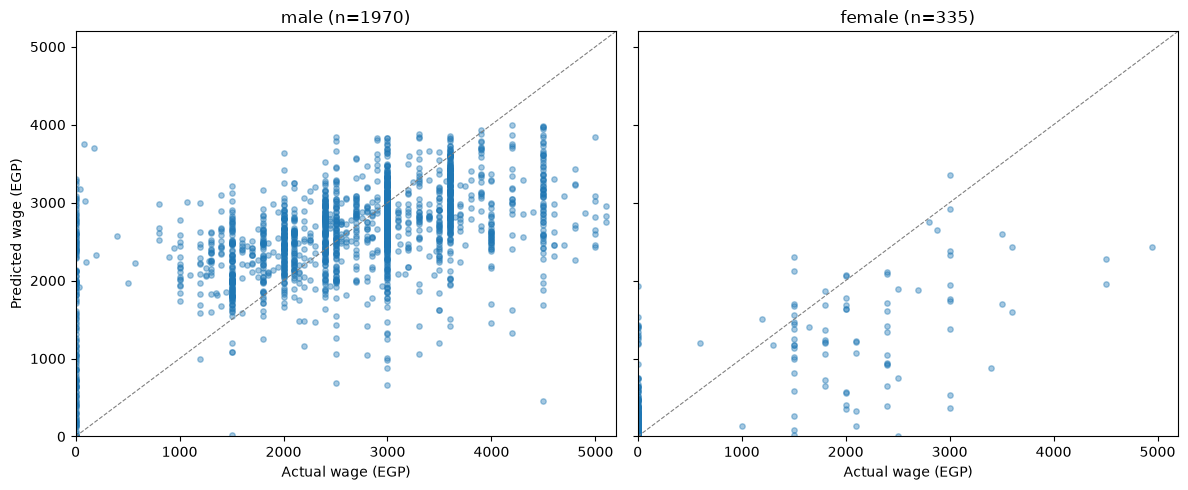

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, sex_label in zip(axes, ["male", "female"]):
    info = LAST_MODELS[sex_label]
    y_true, y_pred = info["y_test"], info["y_pred"]
    ax.scatter(y_true, y_pred, alpha=0.4, s=15)
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual wage (EGP)")
    ax.set_title(f"{sex_label} (n={len(y_true)})")
axes[0].set_ylabel("Predicted wage (EGP)")
plt.tight_layout()
plt.show()


#### 10b. SHAP at the current settings

<div style="font-size: 10pt;">

Feature importance for the model trained in Section 10. Re-run Section 10 after a settings change, then re-run this cell.

</div>

=== male SHAP summary (EMPSTAB=True, HRSWK_F=False, ZERO='none') ===


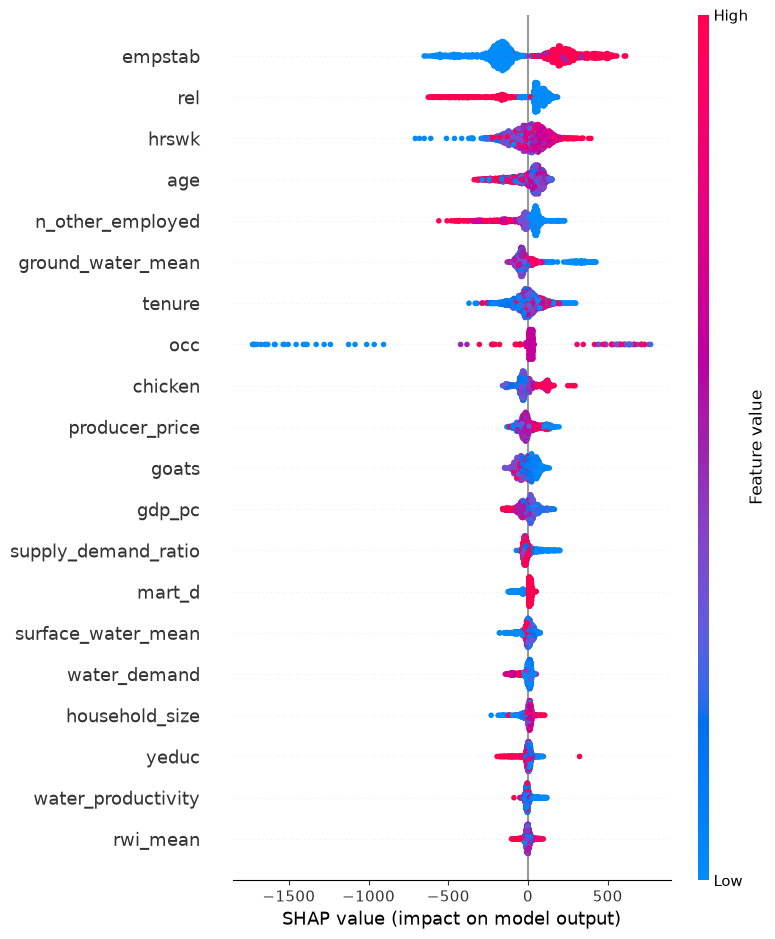

=== female SHAP summary (EMPSTAB=True, HRSWK_F=False, ZERO='none') ===


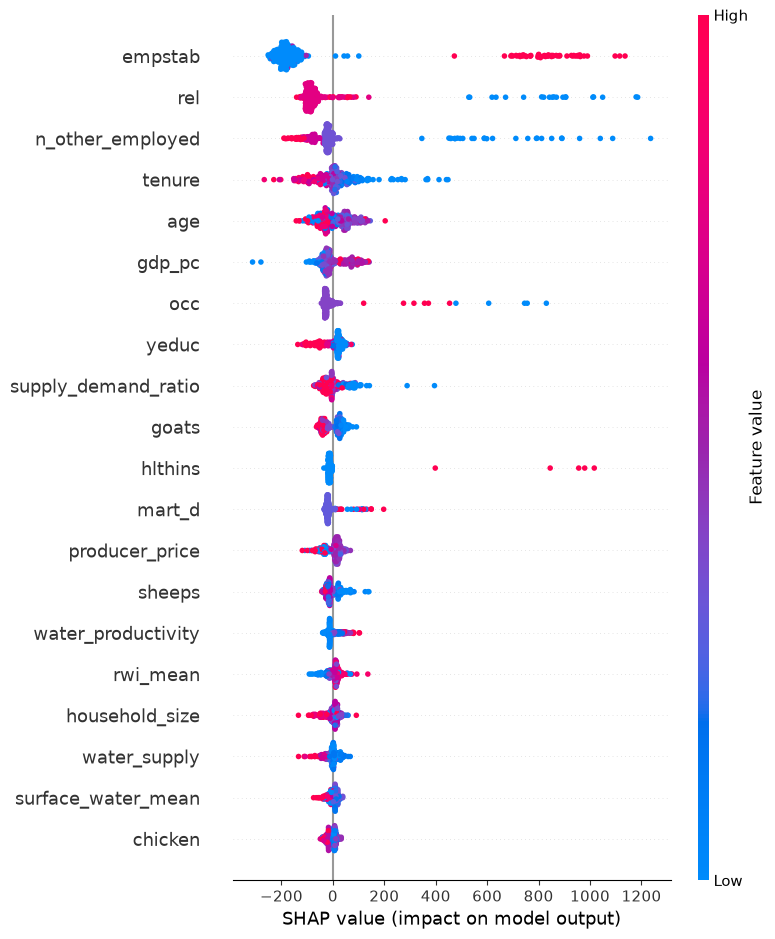

In [21]:
for _sex_label in ["male", "female"]:
    _info = LAST_MODELS[_sex_label]
    _explainer = shap.TreeExplainer(_info["model"])
    _shap_values = _explainer.shap_values(_info["X_test"])
    print(f"=== {_sex_label} SHAP summary ({_config_label}) ===")
    shap.summary_plot(_shap_values, _info["X_test"], show=True)


#### 11. Repeated evaluation across command-unit draws

<div style="font-size: 10pt;">

Only the command-unit draw changes between repetitions; population, features and settings stay fixed. This isolates how much of the result comes from that randomness versus the model itself. Progress prints as it runs.

</div>

In [15]:
import time
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x  # progress bar is a nicety, not a dependency

all_runs = []
gap_runs = []
start_time = time.time()
PRINT_EVERY = max(1, N_REPS // 20)  # ~20 status lines total, regardless of N_REPS

for i in tqdm(range(N_REPS), desc="command-unit reassignment reps"):
    res, gap = run_once(seed=1000 + i)
    for sex_label, m in res.items():
        all_runs.append(m)
    gap_runs.append(gap)

    if (i + 1) % PRINT_EVERY == 0 or (i + 1) == N_REPS:
        elapsed = time.time() - start_time
        rate = elapsed / (i + 1)
        eta_min = rate * (N_REPS - (i + 1)) / 60
        running = pd.DataFrame(all_runs)
        male_r2 = running.loc[running["label"] == "male", "r2"].median()
        female_r2 = running.loc[running["label"] == "female", "r2"].median()
        print(f"[rep {i + 1}/{N_REPS}]  elapsed={elapsed/60:.1f} min  "
              f"est. remaining={eta_min:.1f} min  "
              f"running median R²: male={male_r2:.3f}  female={female_r2:.3f}")

runs_df = pd.DataFrame(all_runs)
gaps_df = pd.DataFrame(gap_runs)

print(f"\n=== {N_REPS} repetitions, percentile summary ===\n")
for sex_label in ["male", "female"]:
    sub = runs_df[runs_df["label"] == sex_label]
    print(f"--- {sex_label} ---")
    print(sub[["mae", "rmse", "r2", "spearman"]].describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%"]])
    print()

print("--- predicted vs. observed gender gap across repetitions ---")
print(gaps_df.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%"]])


command-unit reassignment reps:  10%|█         | 1/10 [00:53<07:59, 53.30s/it]

[rep 1/10]  elapsed=0.9 min  est. remaining=8.0 min  running median R²: male=0.356  female=0.593


command-unit reassignment reps:  20%|██        | 2/10 [01:50<07:22, 55.32s/it]

[rep 2/10]  elapsed=1.8 min  est. remaining=7.3 min  running median R²: male=0.364  female=0.594


command-unit reassignment reps:  30%|███       | 3/10 [03:04<07:29, 64.20s/it]

...

[rep 8/10]  elapsed=8.3 min  est. remaining=2.1 min  running median R²: male=0.361  female=0.592


command-unit reassignment reps:  90%|█████████ | 9/10 [09:16<00:58, 58.36s/it]

[rep 9/10]  elapsed=9.3 min  est. remaining=1.0 min  running median R²: male=0.356  female=0.592


command-unit reassignment reps: 100%|██████████| 10/10 [10:12<00:00, 61.29s/it]

[rep 10/10]  elapsed=10.2 min  est. remaining=0.0 min  running median R²: male=0.359  female=0.590

=== 10 repetitions, percentile summary ===

--- male ---
            mae        rmse        r2  spearman
5%   654.819510  919.577656  0.346989  0.573776
50%  666.984633  928.156244  0.358969  0.583785
95%  674.841317  937.889009  0.371716  0.599092

--- female ---
            mae        rmse        r2  spearman
5%   366.282422  633.684232  0.576533  0.616342
50%  381.599982  650.237469  0.590078  0.629099
95%  395.314407  671.740677  0.605850  0.656284

--- predicted vs. observed gender gap across repetitions ---
     predicted_gap  observed_gap
5%     2021.261128   1988.373120
50%    2058.067732   2022.111084
95%    2082.803960   2043.832062


#### 11b. Distribution across the 100 command-unit draws

<div style="font-size: 10pt;">

Box plots built from `runs_df` and `gaps_df` (both set in Section 11), showing the full spread behind the P5/P50/P95 numbers above, not just the three percentile points. Needs Section 11 to have run in this kernel session; if it prints a message asking you to re-run Section 11, that means the kernel was restarted since the last run and those two variables are gone from memory.

</div>

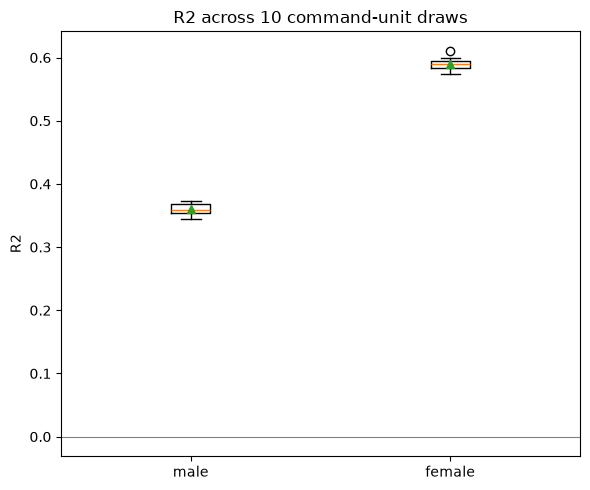

male: median=0.359  IQR=[0.355, 0.369]  min=0.345  max=0.372
female: median=0.590  IQR=[0.583, 0.594]  min=0.575  max=0.611


In [18]:
if "runs_df" not in globals():
    print("runs_df not found in memory -- re-run Section 11 first, then re-run this cell.")
else:
    fig, ax = plt.subplots(figsize=(6, 5))
    r2_by_sex = [runs_df.loc[runs_df["label"] == sex, "r2"].values for sex in ["male", "female"]]
    ax.boxplot(r2_by_sex, tick_labels=["male", "female"], showmeans=True)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"R2 across {len(runs_df) // 2} command-unit draws")
    ax.set_ylabel("R2")
    plt.tight_layout()
    plt.show()

    for sex in ["male", "female"]:
        sub = runs_df.loc[runs_df["label"] == sex, "r2"]
        print(f"{sex}: median={sub.median():.3f}  IQR=[{sub.quantile(0.25):.3f}, {sub.quantile(0.75):.3f}]  "
              f"min={sub.min():.3f}  max={sub.max():.3f}")
